# 🔍 Insight Engine — Phase 1: Understand the Data (EDA)

> **Goal of this notebook:** Before we build anything, we must *understand* our data.
> This is called **EDA (Exploratory Data Analysis)** — the first step of any real data
> project. We check: how big it is, what it contains, where the holes (missing values) are,
> and any quirks we must handle later.

**The data:** ~125,000 real U.S. credit-card complaints (2023–present) from the CFPB
(Consumer Financial Protection Bureau), each with a written customer narrative.

**Why it matters:** garbage in → garbage out. If we don't know our data, every result later
is untrustworthy. By the end of this notebook we will be able to *defend* our dataset.

## 🟦 Cell 1 — Import our tools

**What this does:** loads the Python libraries we need.
- `pandas` → work with data tables (like Excel, in code). We nickname it `pd`.
- `matplotlib` & `seaborn` → make charts. Nicknamed `plt` and `sns`.

**What we expect:** no output. If it runs with no error, the tools are ready.

In [1]:
# Import the libraries we'll use throughout this notebook.
import pandas as pd            # data tables
import matplotlib.pyplot as plt # charts
import seaborn as sns          # prettier charts on top of matplotlib

# Make charts look clean and readable.
sns.set_theme(style="whitegrid")

print("Libraries loaded. Ready to go.")

Libraries loaded. Ready to go.


## 🟦 Cell 2 — Load our clean data slice

**What this does:** reads our clean 176 MB credit-card file into a table called `df`
(short for *dataframe* — pandas' name for a data table).

> We use the small clean slice we carved from the 8.5 GB raw file — NOT the giant file.

**What we expect:** it prints the shape = (rows, columns). We expect ~124,962 rows and 16 columns.

In [2]:
# Path to our clean working file (Parquet - robust for text, keeps data types).
DATA_PATH = "../data/creditcard_complaints.parquet"

# Read the Parquet file into a dataframe.
df = pd.read_parquet(DATA_PATH)

# .shape gives (number_of_rows, number_of_columns).
print("Rows, Columns:", df.shape)

Rows, Columns: (124962, 16)


**📖 Interpretation:** `df` now holds ~125k credit-card complaints across 16 columns.
Each row = one real complaint. This small file is all the project needs from here on.

## 🟦 Cell 3 — First look: peek at a few rows

**What this does:** `.head()` shows the first 3 rows so we can eyeball the actual content.

**What we expect:** a table; note the `Consumer complaint narrative` column — that's our gold (the text).

In [3]:
# Show the first 3 complaints. .head(n) returns the top n rows.
df.head(3)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
0,2025-12-16 16:27:27,Credit card,Store credit card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,"In XX/XX/year>, XXXX, through XXXX, applied ch...",Company believes it acted appropriately as aut...,Atlanticus Services Corporation,IL,60803,"Older American, Servicemember",Web,2026-01-07T16:21:37.000Z,Closed with non-monetary relief,Yes,18079342.0
1,2026-01-14 17:36:29,Credit card,General-purpose credit card or charge card,"Advertising and marketing, including promotion...",Didn't receive advertised or promotional terms,"On XX/XX/year>, Adobe replied only to say they...",NaN,Pending Company Match,FL,34135,Older American,Web,2026-01-20T20:50:48.000Z,NaN,Yes,18719322.0
2,2026-02-19 03:42:52,Credit card,General-purpose credit card or charge card,"Advertising and marketing, including promotion...",Didn't receive advertised or promotional terms,Chase is using many tactics to steal money fro...,NaN,JPMORGAN CHASE & CO.,CA,92504,NaN,Web,2026-02-19T05:16:33.000Z,Closed with explanation,Yes,19611899.0


**📖 Interpretation:** each row is a real complaint with a date, product, the customer's
written story (narrative), the company, and how it was resolved. This confirms the file is intact.

## 🟦 Cell 3b — Run the automatic VALIDATION report

**What this does:** runs our reusable `validate()` tool (from `data_checks.py`). It checks
shape, required columns, missing %, duplicates, text quality, date validity, and label
consistency — all at once.

**Why (our rule):** *the data is the foundation.* We validate BEFORE acting, and re-validate
after every transformation. A step isn't 'done' until we confirm it did what we intended.

**What we expect:** all critical checks OK; the only known issue is 2 product labels to merge.

In [4]:
# Import our reusable validation tool (lives next to this notebook).
from data_checks import validate

# Run the full report on our loaded data.
validate(
    df,
    text_col="Consumer complaint narrative",
    date_col="Date received",
    label_col="Product",
    expected_cols=["Date received", "Product", "Consumer complaint narrative", "Company"],
)

DATA VALIDATION REPORT
[1] SHAPE            : 124,962 rows  x  16 columns
[2] REQUIRED COLUMNS : all present   OK
[3] TOP MISSING %    : {'Tags': np.float64(81.4), 'Company public response': np.float64(53.0), 'State': np.float64(0.4), 'Sub-issue': np.float64(0.4), 'Company response to consumer': np.float64(0.1)}


[4] DUPLICATE ROWS   : 0   OK


[5] TEXT 'Consumer complaint nar...' : empty=0, median_len=862 chars, very_short(<20)=9
[6] DATE 'Date received' : range 2023-01-01 00:00:00 -> 2026-07-02 03:40:24 | invalid=OK
[7] LABELS 'Product' : 2 distinct ->
         105,790  |  Credit card
          19,172  |  Credit card or prepaid card
Review each line above. Anything marked FAIL/CHECK must be fixed before moving on.


**📖 Interpretation:** the report confirms the data is sound: ~125k rows, no duplicates, no
empty narratives, all dates valid across 2023–2026. The only flagged item is the two
credit-card product labels — which we deliberately merge in Phase 2. Now we can trust this data.

## 🟦 Cell 4 — Where are the holes? (missing values / nulls)

**What this does:** counts missing values in each column. A *null* = an empty cell.
Knowing where data is missing tells us which columns we can trust and which to ignore.

**What we expect:** key columns (Date, Product, narrative, Company) should be full;
some columns (like Tags) will be mostly empty.

In [5]:
# Count nulls per column, and show as a % of total rows, sorted worst-first.
nulls = df.isnull().sum()
null_pct = (nulls / len(df) * 100).round(1)
null_report = pd.DataFrame({"missing_count": nulls, "missing_%": null_pct})
null_report.sort_values("missing_%", ascending=False)

,missing_count,missing_%
Tags,101683,81.4
Company public response,66210,53.0
State,472,0.4
Sub-issue,447,0.4
Company response to consumer,175,0.1
Issue,0,0.0
Date received,0,0.0
Product,0,0.0
Company,0,0.0
Consumer complaint narrative,0,0.0


**📖 Interpretation:** columns with high missing % (e.g. `Tags`) are unreliable — we'll ignore them.
Our critical columns (`Consumer complaint narrative`, `Product`, `Company`, `Date received`)
should be complete or nearly so — meaning the analysis rests on solid ground.

## 🟦 Cell 5 — The messy-label check (a real data-quality issue)

**What this does:** shows how many complaints fall under each `Product` label.

**Why it matters:** CFPB used *different names* for the same product over the years.
We already saw "Credit card" and "Credit card or prepaid card" — the same thing, two labels.

**What we expect:** two credit-card labels that we should treat as one.

In [6]:
# value_counts() counts how many rows have each unique value.
df["Product"].value_counts()

Product
Credit card                    105790
Credit card or prepaid card     19172
Name: count, dtype: int64

**📖 Interpretation:** two labels describe the same real product. In Phase 2 (cleaning) we'll
**merge** them into a single category. Trusting raw labels blindly would split one product in two —
a classic mistake. Catching this is exactly the kind of data-quality awareness interviewers probe.

## 🟦 Cell 6 — Who are the complaints about? (top companies)

**What this does:** lists the 10 companies with the most complaints in our slice.

**What we expect:** big card issuers (Capital One, Citi, Chase, Amex...). Note: some credit
bureaus (Equifax, Experian, TransUnion) also appear — because card issues can involve credit reports.

In [7]:
# Top 10 companies by complaint count.
top_companies = df["Company"].value_counts().head(10)
top_companies

Company
CAPITAL ONE FINANCIAL CORPORATION         14527
CITIBANK, N.A.                            13031
SYNCHRONY FINANCIAL                       10872
JPMORGAN CHASE & CO.                       9522
AMERICAN EXPRESS COMPANY                   7384
BANK OF AMERICA, NATIONAL ASSOCIATION      6791
TRANSUNION INTERMEDIATE HOLDINGS, INC.     5722
EQUIFAX, INC.                              5462
Bread Financial Holdings, Inc.             5244
Experian Information Solutions Inc.        5192
Name: count, dtype: int64

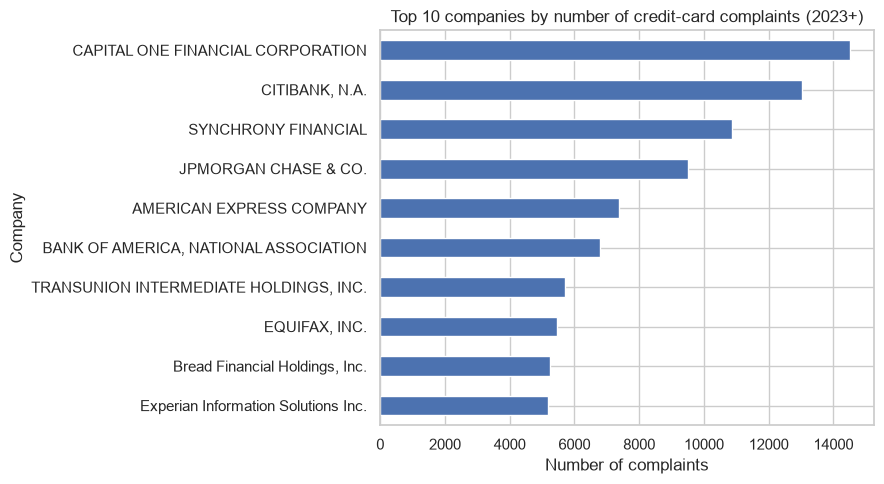

In [8]:
# Visualize it as a horizontal bar chart (easier to read company names).
plt.figure(figsize=(9, 5))
top_companies.sort_values().plot(kind="barh", color="#4C72B0")
plt.title("Top 10 companies by number of credit-card complaints (2023+)")
plt.xlabel("Number of complaints")
plt.tight_layout()
plt.show()

**📖 Interpretation:** the leaders are major card issuers — sensible and realistic. The presence
of credit bureaus reminds us the data is customer-tagged, not perfectly clean; a good nuance to mention.

## 🟦 Cell 7 — How long are the complaint stories?

**What this does:** measures the length (in characters) of each narrative.

**Why it matters:** very short texts ("bad service") carry little signal; the AI step later works
best on real sentences. This tells us the text is substantial enough to mine.

In [9]:
# Length of each narrative in characters.
lengths = df["Consumer complaint narrative"].str.len()
print("Shortest:", int(lengths.min()), "chars")
print("Median  :", int(lengths.median()), "chars")
print("Average :", int(lengths.mean()), "chars")
print("Longest :", int(lengths.max()), "chars")

Shortest: 15 chars
Median  : 862 chars
Average : 1186 chars
Longest : 32785 chars


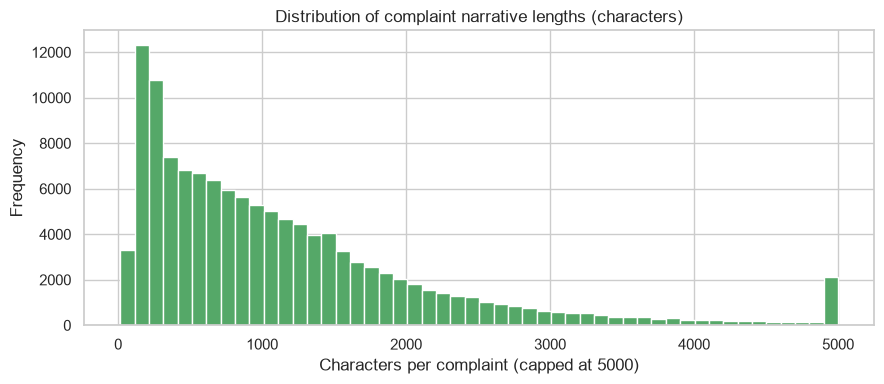

In [10]:
# Distribution of narrative lengths (capped at 5000 chars for a readable chart).
plt.figure(figsize=(9, 4))
lengths.clip(upper=5000).plot(kind="hist", bins=50, color="#55A868")
plt.title("Distribution of complaint narrative lengths (characters)")
plt.xlabel("Characters per complaint (capped at 5000)")
plt.tight_layout()
plt.show()

**📖 Interpretation:** a typical complaint is ~860 characters (a solid paragraph) — plenty of
real text for our NLP engine to find themes. Very few are too short to be useful.

## 🟦 Cell 8 — Complaints over time

**What this does:** counts complaints per month to see the trend.

**What we expect:** a continuous line from late 2023 to mid-2026 — confirms our date filter worked.

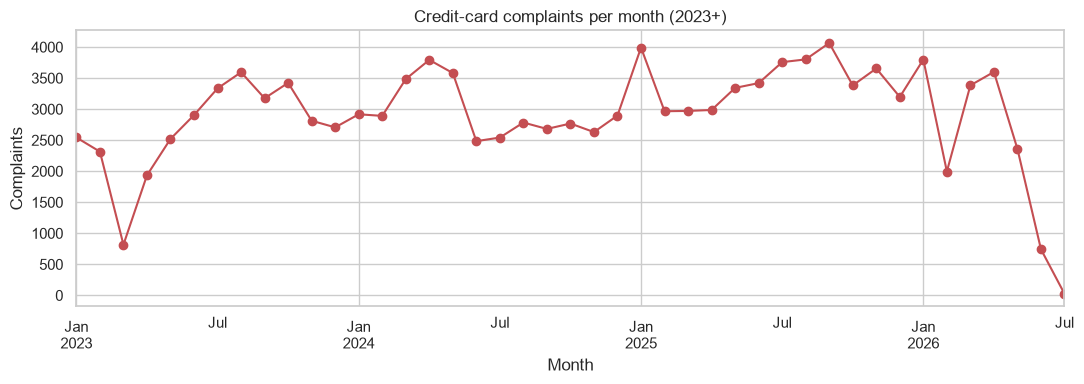

In [11]:
# 'Date received' is already a clean datetime in the Parquet file.
# Count complaints per month to see the trend.
per_month = df["Date received"].dt.to_period("M").value_counts().sort_index()

plt.figure(figsize=(11, 4))
per_month.plot(kind="line", marker="o", color="#C44E52")
plt.title("Credit-card complaints per month (2023+)")
plt.ylabel("Complaints")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

**📖 Interpretation:** the volume trend tells us how complaint load changes over time — useful
context for the business (rising complaints = growing problem). Confirms our slice spans the
expected period with no big gaps.

---
## ✅ Phase 1 summary (what we learned)
- ~125k real credit-card complaints, 2023–mid-2026, all with written narratives.
- Key columns are complete; some columns (Tags etc.) are mostly empty and will be ignored.
- **Data-quality issue found:** the product appears under two labels → must merge in Phase 2.
- Narratives are substantial (~860 chars median) → great raw material for NLP.
- Top companies are the expected big card issuers → data looks realistic and trustworthy.

**Next (Phase 2):** clean the text — merge product labels, remove duplicates, strip the CFPB
`XXXX` privacy masks, and prepare the narratives for the NLP engine.